In [1]:
from cirq_sic import *

## All $d=2$ fiducials and the Bloch sphere

In [2]:
sic_states = all_d2_fiducials(); sic_states

array([[ 0.888+0.j   ,  0.325+0.325j],
       [ 0.888+0.j   , -0.325-0.325j],
       [ 0.325+0.325j,  0.888+0.j   ],
       [-0.325-0.325j,  0.888-0.j   ],
       [ 0.325-0.325j,  0.888+0.j   ],
       [ 0.325-0.325j, -0.888+0.j   ],
       [ 0.888-0.j   ,  0.325-0.325j],
       [-0.888+0.j   ,  0.325-0.325j]])

In [3]:
np.array([bloch_vector(e) for e in sic_states])

array([[ 0.577,  0.577,  0.577],
       [-0.577, -0.577,  0.577],
       [ 0.577, -0.577, -0.577],
       [-0.577,  0.577, -0.577],
       [ 0.577,  0.577, -0.577],
       [-0.577, -0.577, -0.577],
       [ 0.577, -0.577,  0.577],
       [-0.577,  0.577,  0.577]])

In [4]:
d = 2
phi = load_sic_fiducial(2) # it's on the list above!
phi = phi*np.exp(-1j*np.angle(phi[0])); phi # fix global phase

array([0.888-0.j   , 0.325-0.325j])

In [5]:
WH = wh_operators(2)
Z, X = WH["Z"], WH["X"]
D = [np.eye(d), Z, X, Z @ X]
labels = ["I", "Z", "X", "ZX"]
orbit = [bloch_vector(O @ phi) for O in D]

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from itertools import combinations

def set_axes_equal(ax):
    """
    Make 3D axes have equal scale.

    Uses `set_box_aspect([1,1,1])` when available (Matplotlib 3.3+).
    Otherwise falls back to setting equal limits on x/y/z.
    """
    try:
        ax.set_box_aspect([1, 1, 1])
        return
    except Exception:
        pass

    # Fallback: compute ranges and set equal limits
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_mid = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_mid = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_mid = np.mean(z_limits)

    max_range = 0.5 * max([x_range, y_range, z_range])

    if max_range == 0:
        max_range = 1.0  # sensible default if all points identical

    ax.set_xlim3d([x_mid - max_range, x_mid + max_range])
    ax.set_ylim3d([y_mid - max_range, y_mid + max_range])
    ax.set_zlim3d([z_mid - max_range, z_mid + max_range])

def plot_bloch_sics(orbits, labels):
    orbits = np.asarray(orbits)
    labels = list(labels)

    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)
    x_s = np.outer(np.cos(u), np.sin(v))
    y_s = np.outer(np.sin(u), np.sin(v))
    z_s = np.outer(np.ones_like(u), np.cos(v))

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(x_s, y_s, z_s, color='lightgrey', alpha=0.25, linewidth=0, zorder=0)
    ax.plot_wireframe(x_s, y_s, z_s, color='lightgrey', rstride=3, cstride=3, linewidth=0.7, alpha=0.6, zorder=0)

    colors = ["black", "blue", "green", "red"]
    for k, orbit in enumerate(orbits):
        ax.scatter(orbit[:, 0], orbit[:, 1], orbit[:, 2],
            color=colors[k], s=150, edgecolor='k', linewidth=0.5, depthshade=True, zorder=3)
    
        for i, j in combinations(range(len(orbit)), 2):
            p1 = orbit[i]; p2 = orbit[j]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                    color=colors[k], linewidth=1, alpha=0.8, zorder=2)

        offset_factor = 0.06
        for (x0, y0, z0), lab in zip(orbit, labels):
            vec = np.array([x0, y0, z0], dtype=float)
            norm = np.linalg.norm(vec)
            text_pos = vec + np.array([0.02, 0.02, 0.02]) if norm == 0 else vec * (1.0 + offset_factor / norm)
            ax.text(text_pos[0], text_pos[1], text_pos[2],
                    f'{lab}', fontsize=12, color=colors[k], horizontalalignment='left', verticalalignment='center', zorder=4)

    set_axes_equal(ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

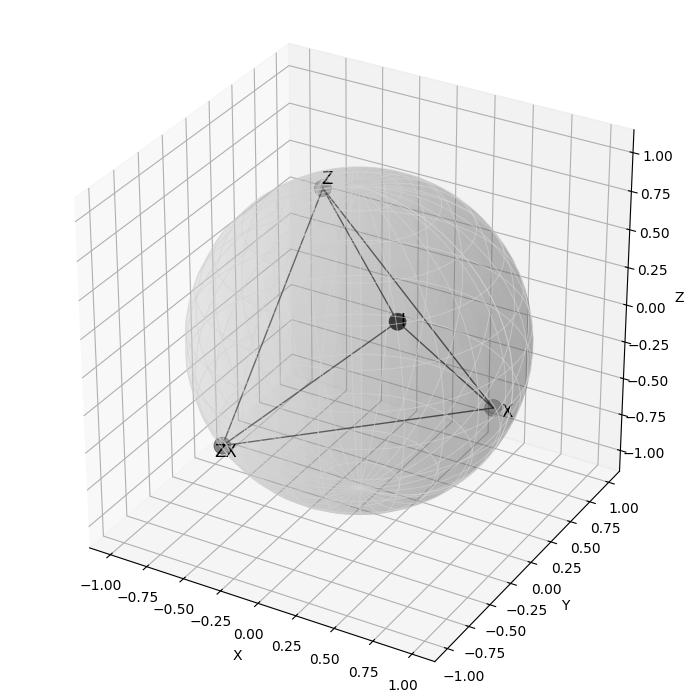

In [7]:
%matplotlib widget 
plot_bloch_sics([orbit], labels)

## Error Analysis

In [12]:
data = [{'E1': 0.491, 'E2': 0.189, 'E4': 0.17, 'E3': 0.15},
        {'E3': 0.185, 'E2': 0.488, 'E1': 0.177, 'E4': 0.15},
        {'E1': 0.226, 'E2': 0.179, 'E3': 0.44, 'E4': 0.155},
        {'E4': 0.438, 'E3': 0.151, 'E2': 0.237, 'E1': 0.174}]

In [18]:
data = [{'E1': 0.475056, 'E2': 0.211156, 'E4': 0.140938, 'E3': 0.17285},
        {'E1': 0.231473, 'E2': 0.444333, 'E3': 0.148823, 'E4': 0.175371},
        {'E3': 0.477006, 'E4': 0.151367, 'E1': 0.168641, 'E2': 0.202986},
        {'E4': 0.473319, 'E2': 0.166838, 'E3': 0.161003, 'E1': 0.19884}]

In [19]:
E = wh_povm(load_sic_fiducial(2))
Phi = np.linalg.inv(SIC_P(2))
indices = ["E1", "E2", "E3", "E4"]

M = np.array([[row[ind] for ind in indices] for row in data])
empirical_rhos = [sum([c*E[i]/E[i].trace() for i, c in enumerate(Phi @ m)]) for m in M]
empirical_orbit = [bloch_vector(rho) for rho in empirical_rhos]

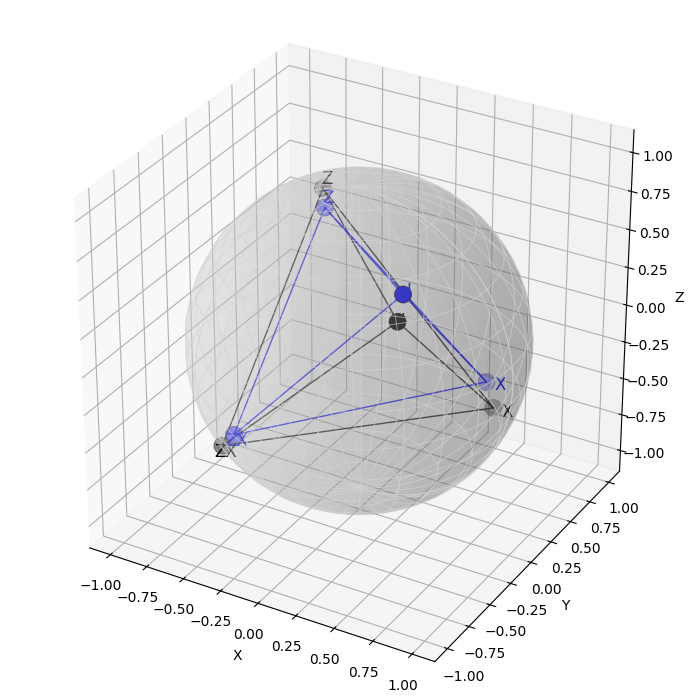

In [20]:
plot_bloch_sics([orbit, empirical_orbit], labels)